### 08. Generation of a cleaned filament sample

This notebook uses the filament catalog generated using DisPerSe.

**Author**: Soumya Shreeram <br/>
**Date created**: 29th August 2022 <br/>
**Last edited**: tbu <br/>

In [1]:
# astropy modules
import astropy.units as u
import astropy.io.fits as fits
from astropy.table import Table, Column, QTable
from astropy.coordinates import SkyCoord
from astropy.cosmology import Planck18, z_at_value

from astrotools import healpytools as hpt
from gdpyc import GasMap
    
import numpy as np

# system imports
import os
import sys
import importlib as ib
import glob
import copy

# plotting imports
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.lines import Line2D
from matplotlib import cm
import seaborn as sns

import healpy as hp
from healpy.newvisufunc import projview, newprojplot

In [2]:
import filaments as fo

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
mpl.rcParams['agg.path.chunksize'] = 100000
%matplotlib inline
font = {'family' : 'serif',
        'weight' : 'medium',
        'size'   : 16}
mpl.rc('font', **font)

bright_colors = sns.color_palette("bright")

Input parameters

In [5]:
base_dir = "/data53s/shreeram/Filament_stacking"

# decides wether to produce the fits file for critical points "cp", filaments "fil" or "cp_field"
keyword = "fil" 

# system keywords
data_set = 'lc_north_dis' # 'legacy_north_dis' for Legacy MGS, 'lc_north_dis' for LOWZ+CMASS
smoothing_density_f = 'None' # 'None' or 'SD1' or 'SD2'
persistence =  3 # 3 or 5
smoothing_skeleton = 'None' # None or 'S001'
base_name = f"{data_set}_{smoothing_density_f}_{persistence:.1f}_{smoothing_skeleton}"
base_name2 = f"legacy_north_dis_{smoothing_density_f}_{persistence:.1f}_{smoothing_skeleton}"

ra_c_MGS, dec_c_MGS = 186.183, 26.845
ra_c_LOWZ, dec_c_LOWZ = 184.894, 28.153
"""
For the healpy map
"""
z_low, z_high = 0.1, 0.2
z_range = (z_low, z_high)

# can change this default value in the class objects below
NSIDE = 512
val_erass1 = 2
val_combined = val_erass1+1

milky_way_map = fo.get_milky_way()

In [6]:
this_file = fo.DisPerSEcatalog(data_set=data_set, 
                               smoothing_density_f = smoothing_density_f, 
                               persistence = persistence, 
                               smoothing_skeleton = smoothing_skeleton,
                               section_keyword = keyword)

INFO:DisPerSEcatalog:<DisPerSEcatalog(data_set=lc_north_dis, smoothing_density_f=None, persistence=3, smoothing_skeleton=None)>


The following 3 code blocks go into the method `get_ra_dec_z()` in tne class `DisperseCatalog`

In [7]:
t = Table.read(f'{this_file.reformatted_filename}.fit')
print(f'{this_file.reformatted_filename}.fit')
t[40]

/data53s/shreeram/Filament_stacking/data/Filament_catalogues/Malavasi_2020_SDSS/Reformatted/lc_north_dis_None_3.0_None_fil.fit


cp1,cp2,n_samp,pos_x_arr,pos_y_arr,pos_z_arr,Fil_lengths_Mpc,Orientation_radian,RMS,Ownership,Nh_flag_relaxed,Nh_val_relaxed,Elongation,Nh_flag_conservative,Nh_val_conservative
int64,int64,int64,bytes282,bytes284,bytes317,float64,float64,float64,bytes32,float64,bytes734,float64,float64,bytes734
9845,9848,6,"1647.67, 1664.51, 1672.36, 1685.1, 1695.43","623.363, 626.014, 630.81, 632.13, 630.578","-272.009, -271.598, -272.334, -270.695, -263.518",64.32543256874803,0.38772086801362193,77753.06643974905,DE,1.0,"0.01516815170325335, 0.01516815170325335, 0.014974841245002505, 0.014892495939350178, 0.014729530540057224, 0.01596978716868618, 0.014619754426380834",0.2375870656524827,1.0,"0.01516815170325335, 0.01516815170325335, 0.014974841245002505, 0.014892495939350178, 0.014729530540057224, 0.01596978716868618, 0.014619754426380834"


Now that we have the RA, Dec and reshift, let's go ahead and accumulate the filaments! Filaments are defined as 

In [7]:
def get_tables(this_file, base_name, keyword='cp'):
    "Function opens the table for the selected keyword"
    example = f'{base_name}_{keyword}.fit'
    example_with_extras = f'{base_name}_{keyword}_extras.fit'
    
    table_example = Table.read(f'{this_file.catalog_dir_reformatted}/{example}')
    table_example_extras = Table.read(f'{this_file.catalog_dir_reformatted}/{example_with_extras}')
    return table_example, table_example_extras

def plot_healpy_maps(this_file, base_name, z_low = 0.1, z_high = 0.2, NSIDE = 512, 
                     title='LOWZ+CMASS', id_type='filaments',vmax=1.1, ra_c_MGS = 186.183, 
                     dec_c_MGS = 26.845, ra_c_LOWZ = 184.894, dec_c_LOWZ = 28.153,
                    keyword='fil'):
    "Function to quickly check the generated fits tables"
    example_with_extras = f'{base_name}_{keyword}_extras.fit'
    table_extra = Table.read(f'{this_file.catalog_dir_reformatted}/{example_with_extras}')
    select_z = (z_low < table_extra['redshift']) & (table_extra['redshift'] < z_high)
    
    milky_way_map = fo.get_milky_way()
    if title == 'LOWZ+CMASS':
        ra_c, dec_c = ra_c_LOWZ, dec_c_LOWZ
    if title == 'MGS':
        ra_c, dec_c = ra_c_MGS, dec_c_MGS
    
    ra, dec = table_extra['RA'] + ra_c, table_extra['DEC'] +  dec_c
    fil_map = fo.produce_healpy_map(NSIDE, ra[select_z], dec[select_z])

    # plot healpy map
    fo.healpy_mollview(fil_map+milky_way_map, title=f"{title}, {id_type}", vmax=vmax, 
                       rot=[270, 0])
    return fil_map

Checking if the redshift distribution matches the one from the paper for Lowz+cmass and for Main Galaxy sample of SDSS

In [8]:
table_fil, table_fil_extras = get_tables(this_file, base_name, keyword='fil')
table_fil2, table_fil_extras2 = get_tables(this_file, base_name2, keyword='fil')

table_cp, table_cp_extras = get_tables(this_file, base_name, keyword='cp')
table_cp2, table_cp_extras2 = get_tables(this_file, base_name2, keyword='cp')

<AxesSubplot:title={'center':'Redshift distribution, LOWZ+CMASS'}, xlabel='redshifts', ylabel='Fraction'>

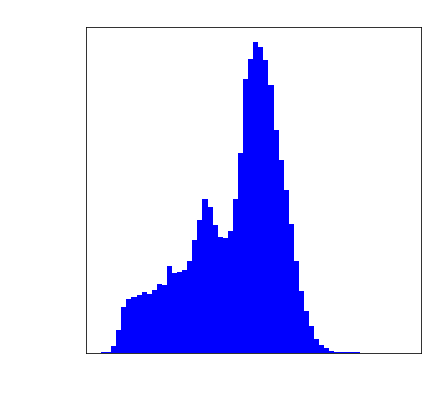

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(6,6))
ax.hist(table_fil_extras['redshift'], bins=60, color='b')

fo.set_labels(ax, xlabel='redshifts', ylabel='Fraction', title='Redshift distribution, LOWZ+CMASS')
fo.set_as_white(ax)

<AxesSubplot:title={'center':'Redshift distribution, MGS'}, xlabel='redshifts', ylabel='Fraction'>

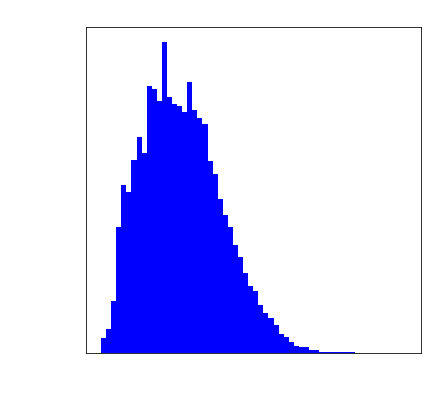

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(6,6))
ax.hist(table_fil_extras2['redshift'], bins=60, color='b')

fo.set_labels(ax, xlabel='redshifts', ylabel='Fraction', title='Redshift distribution, MGS')
fo.set_as_white(ax)

Can also check [here](https://cds.cern.ch/record/2276002/plots) for comparison with the eBOSS footprint 

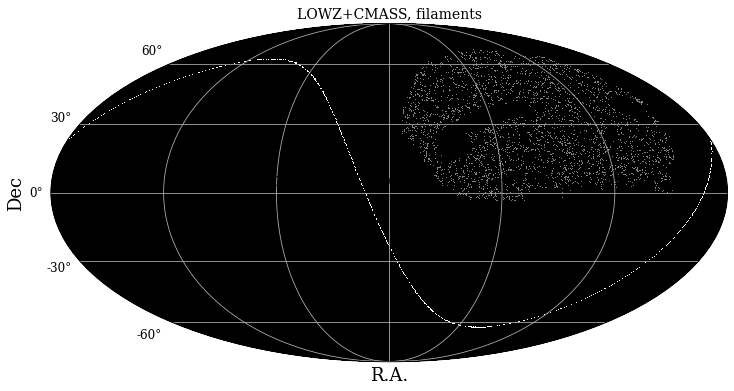

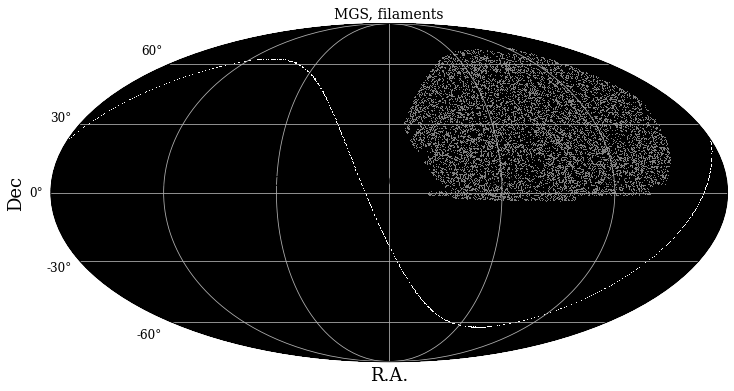

In [76]:
fil_map = plot_healpy_maps(this_file, base_name, title='LOWZ+CMASS',  NSIDE=256)
fil_map2 = plot_healpy_maps(this_file, base_name2, title='MGS', NSIDE=256)

array([0., 0., 0., ..., 0., 0., 0.])

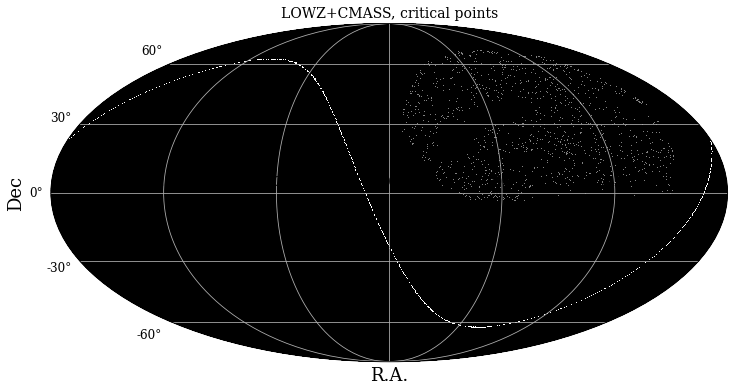

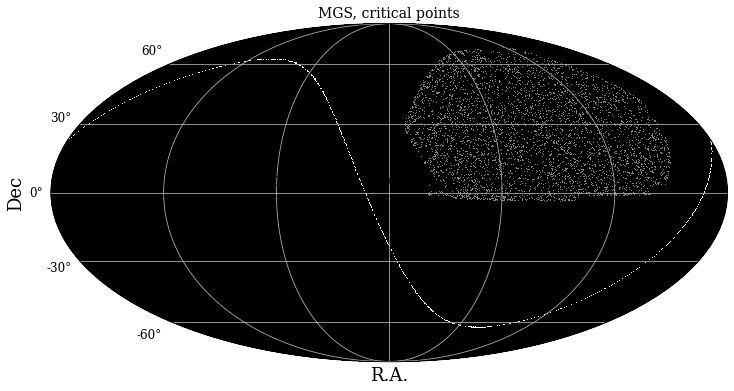

In [77]:
plot_healpy_maps(this_file, base_name, title='LOWZ+CMASS', id_type='critical points', keyword='cp',  NSIDE=256)
plot_healpy_maps(this_file, base_name2, title='MGS', id_type='critical points', keyword='cp', NSIDE=256)

<AxesSubplot:title={'center':'MGS'}, xlabel='Filament lengths [Mpc]', ylabel='Counts'>

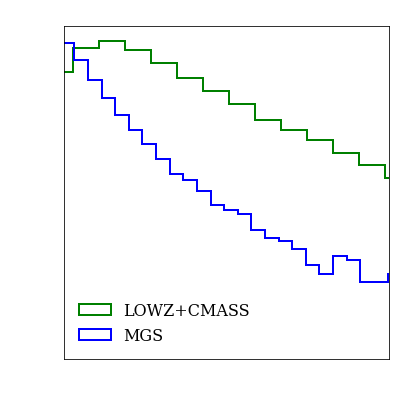

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(6,6), tight_layout=True)
length_fil_arr = table_fil['Fil_lengths_Mpc']
length_fil_arr2 = table_fil2['Fil_lengths_Mpc']
_ = ax.hist(length_fil_arr, histtype='step', linewidth=2, 
            color='g', bins=100, label='LOWZ+CMASS')
_ = ax.hist(length_fil_arr2, histtype='step', linewidth=2, 
            color='b', bins=100, label='MGS')

fo.set_labels(ax, xlabel='Filament lengths [Mpc]', ylabel='Counts',
              title='MGS', log_scale=[True, 'y'], legend=False,
              xlim=[10, 200])
ax.legend(loc= 'lower left', frameon=False)
fo.set_as_white(ax)

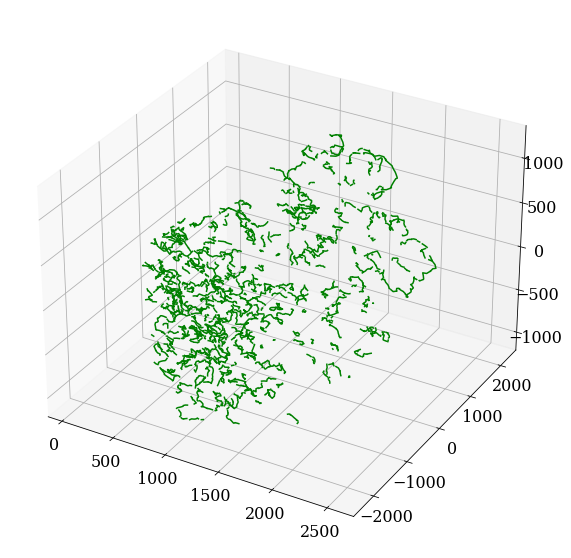

In [80]:
fig = plt.figure(figsize=(10,10))
ax = plt.axes(projection='3d')
for i in range(2000):
    pos_x = np.array(table_fil[i]['pos_x_arr'].split(',')).astype(float)
    pos_y = np.array(table_fil[i]['pos_y_arr'].split(',')).astype(float)
    pos_z = np.array(table_fil[i]['pos_z_arr'].split(',')).astype(float)

    ax.plot3D(pos_x, pos_y, pos_z, 'green')

In [73]:
cluster_cat_eRASS1 = fo.ClusterCatalogs(redshift_range=(0.1, 0.2))
cluster_cat_combined = fo.ClusterCatalogs(this_cluster_cat_name='combined', redshift_range=z_range)

# produce the healpy maps with discs around the clusters
eRASS1 = cluster_cat_eRASS1.get_healpy_clusters_map(fil_pixel_cluster_disc=val_erass1, NSIDE=256)
clu_map_eRASS1, clu_map_with_discs_eRASS1, clu_pix_idx_eRASS1 = eRASS1

combined = cluster_cat_combined.get_healpy_clusters_map(fil_pixel_cluster_disc= val_combined,
                                                        NSIDE=256)
clu_map_combined, clu_map_with_discs_combined, clu_pix_idx_combined = combined

INFO:ClusterCatalogs:Default cluster catalog set to `eRASS1`
INFO:ClusterCatalogs:Other options include: PSZ, ACT
INFO:ClusterCatalogs:Selecting in the redshift bin 0.1<z<0.2
INFO:ClusterCatalogs:catalogs in this file   srccat  
----------
    ACTDR5
      MCXC
      PSZ2
     RXGCC
    XCSDR1
    XClass
    XXL365
     eFEDS
  spt2500d
   spt_ecs
sptpol100d
INFO:ClusterCatalogs:Selecting in the redshift bin 0.1<z<0.2


#### Plotting the filament catalog with the clusters

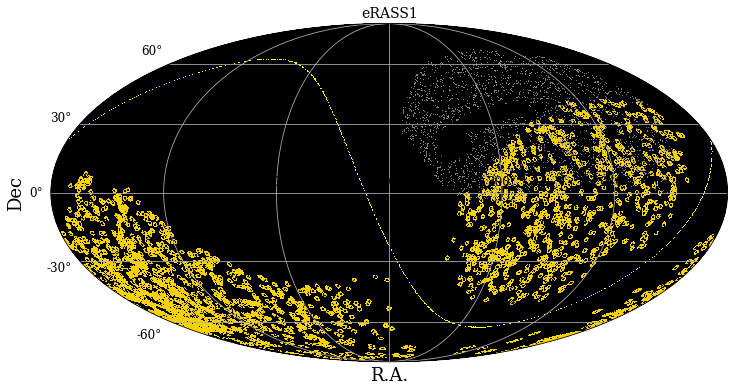

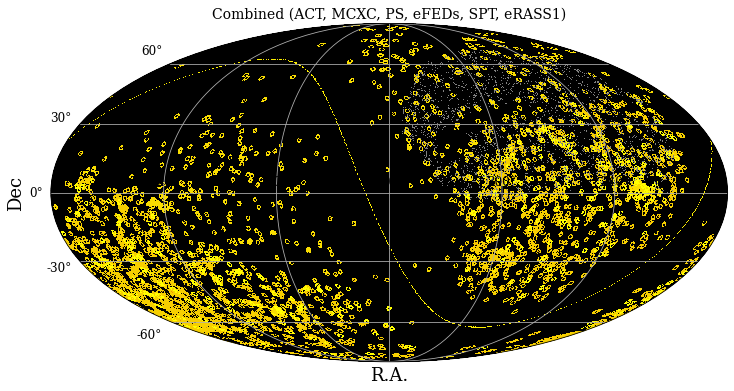

In [78]:
ax = fo.healpy_mollview(clu_map_with_discs_eRASS1+fil_map+milky_way_map, 
                   cmap='gnuplot', title='eRASS1', 
                   vmin=0, vmax=4, norm='hist', rot=[270, 0])
fo.healpy_mollview(clu_map_with_discs_combined+clu_map_with_discs_eRASS1+fil_map+milky_way_map, 
                   cmap='gnuplot', title='Combined (ACT, MCXC, PS, eFEDs, SPT, eRASS1)',
                  vmin=0, vmax=6, norm='hist', rot=[270, 0])

In [67]:
c = SkyCoord(ra_c_LOWZ, dec_c_LOWZ, unit='degree', frame='fk5') 
l_c_LOWZ = c.galactic.l

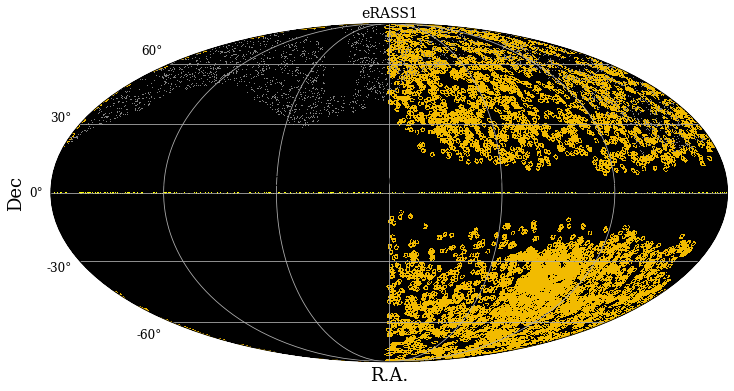

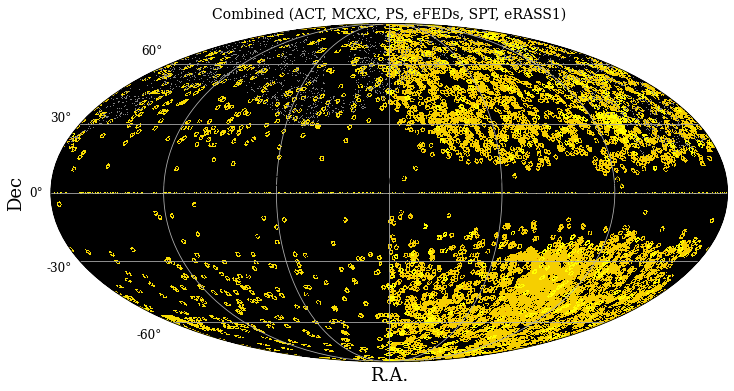

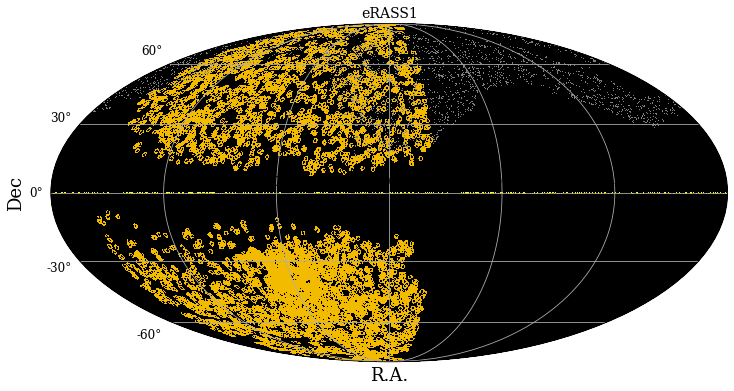

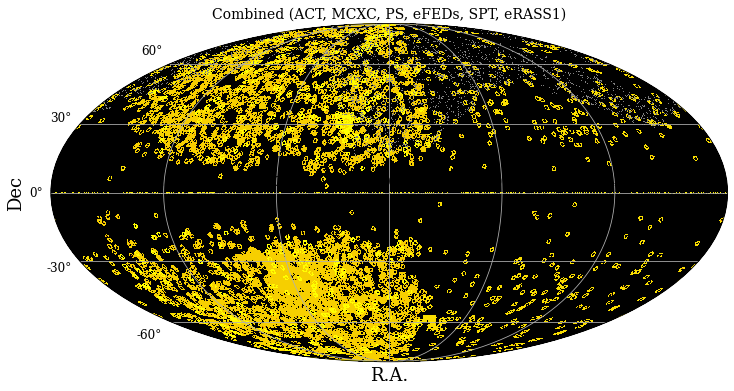

In [72]:
ax = fo.healpy_mollview(clu_map_with_discs_eRASS1+fil_map+milky_way_map, 
                   cmap='gnuplot', title='eRASS1', 
                   vmin=0, vmax=4, norm='hist')
fo.healpy_mollview(clu_map_with_discs_combined+clu_map_with_discs_eRASS1+fil_map+milky_way_map, 
                   cmap='gnuplot', title='Combined (ACT, MCXC, PS, eFEDs, SPT, eRASS1)',
                  vmin=0, vmax=6, norm='hist')
ax = fo.healpy_mollview(clu_map_with_discs_eRASS1+fil_map+milky_way_map, 
                   cmap='gnuplot', title='eRASS1', 
                   vmin=0, vmax=4, norm='hist', rot=[l_c_LOWZ.value, 0])
fo.healpy_mollview(clu_map_with_discs_combined+clu_map_with_discs_eRASS1+fil_map+milky_way_map, 
                   cmap='gnuplot', title='Combined (ACT, MCXC, PS, eFEDs, SPT, eRASS1)',
                  vmin=0, vmax=6, norm='hist', rot=[l_c_LOWZ.value, 0])

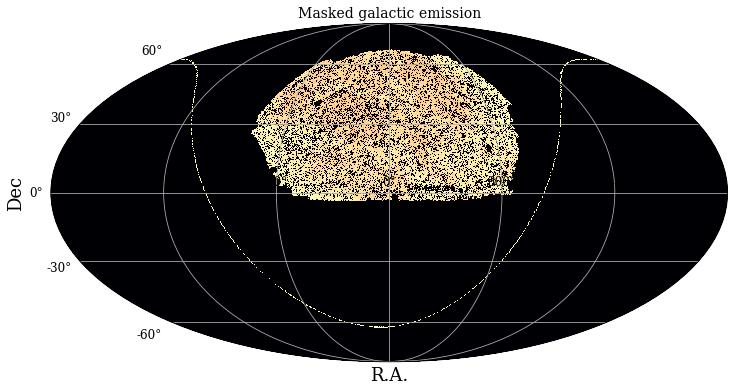

In [24]:
nh_map = fo.get_nh(table_fil_extras['RA']+ra_c_LOWZ, table_fil_extras['DEC']+dec_c_LOWZ, 
                                             res='low', NSIDE_in=256)
fo.healpy_mollview(nh_map+milky_way_map, title='Masked galactic emission', cmap='magma', vmin=0, norm='hist',
                  rot=[ra_c_LOWZ, 0])

### Now we try to make a selection cut based on the $N_h$ values

In [11]:
def plot_length_distribution(table_fil, title='MGS', nh_key='conservative'):
    "Function plots the histogram of the lengths of filaments"
    fig, ax = plt.subplots(1, 1, figsize=(6,6), tight_layout=True)
    length_fil_arr = table_fil['Fil_lengths_Mpc']
    
    # required atleast one of the nh values to have nh>nh_cut
    nh_flag_arr_conservative = table_fil[f'Nh_flag_{nh_key}']
    
    # requires all the filament points to have nh>nh_cut
    nh_flag_arr_relaxed = table_fil[f'Nh_flag_relaxed']
    
    out = ax.hist(length_fil_arr, histtype='step', linewidth=2, 
                color='#ff9999', bins=100, label = 'Full sample')
    out_nh_rel = ax.hist(length_fil_arr[nh_flag_arr_relaxed == 1], histtype='step', linewidth=2, 
                color='#99ff99', bins=100, label='Relaxed $N_h$ cut')
    out_nh_con = ax.hist(length_fil_arr[nh_flag_arr_conservative == 1], histtype='step', linewidth=2, 
                color='#b399ff', bins=100, label='Conservative $N_h$ cut')
    
    fo.set_labels(ax, xlabel='Filament lengths [Mpc]', ylabel='Number of filaments',
                  title=title, log_scale=[True, 'y'], legend=False,
                  xlim=[10, 200])
    ax.legend(loc='lower right',  fontsize=14, frameon=False)

    fo.set_as_white(ax)
    return out, out_nh_con, out_nh_rel

def print_effects_of_length_cuts(out, out_nh_con, out_nh_rel, 
                                len_low = 30, len_high = 100, title='LOWZ+CMASS',
                               nh_key='conservative'):
    """Function digs deeper into understanding the effect of length cuts in combo with Nh cuts
    """
    bin_means = (out_nh_con[1][:-1]+out_nh_con[1][1:])/2
    select_lengths = (bin_means >= len_low) & (bin_means <= len_high)
    
    total_filaments = int(np.sum(out[0][select_lengths]))
    conservative_nh_fil = int(np.sum(out_nh_con[0][select_lengths]))
    relaxed_nh_fil = int(np.sum(out_nh_rel[0][select_lengths]))
    
    print(f"Total number of filaments between {len_low} < len/Mpc< {len_high} in {title} is {total_filaments}" )
    print(f"Conservative foreground absorption cut {conservative_nh_fil}: {conservative_nh_fil*100/total_filaments:.2f}%" )
    print(f"Relaxed foreground absorption cut {relaxed_nh_fil}: {relaxed_nh_fil*100/total_filaments:.2f}%\n" )
    return 

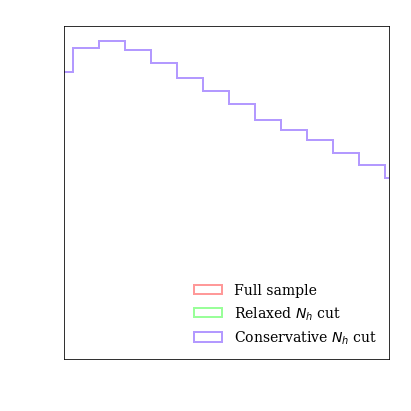

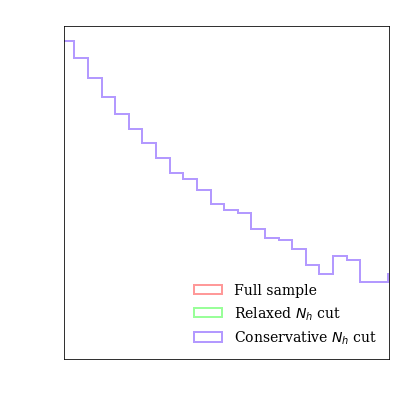

In [26]:
out, out_nh_con, out_nh_rel = plot_length_distribution(table_fil, title='Lowz+CMASS')
out2, out_nh_con2, out_nh_rel2 = plot_length_distribution(table_fil2)

In [32]:
print_effects_of_length_cuts(out, out_nh_con, out_nh_rel)

print_effects_of_length_cuts(out2, out_nh_con2, out_nh_rel2, title='MGS')

Total number of filaments between 30 < len/Mpc< 100 in LOWZ+CMASS is 40096
Conservative foreground absorption cut 40096: 100.00%
Relaxed foreground absorption cut 40096: 100.00%

Total number of filaments between 30 < len/Mpc< 100 in MGS is 6171
Conservative foreground absorption cut 6171: 100.00%
Relaxed foreground absorption cut 6171: 100.00%



### Applying the orientation cut 

In [12]:
def plot_orientation_effect(table_fil, title='MGS'):
    angle_fil_deg = np.rad2deg(table_fil['Orientation_radian'])
    fig, ax = plt.subplots(1, 1, figsize=(5, 5))

    out_angle = ax.hist(angle_fil_deg, histtype='step', linewidth=2, 
                    color='#ff9999', bins=100, label = 'Full sample')
    
    fo.set_as_white(ax)
    fo.set_labels(ax, xlabel='Orientation angle [degrees]', ylabel = 'Number of filaments',
                 title=f'{title}')
    return

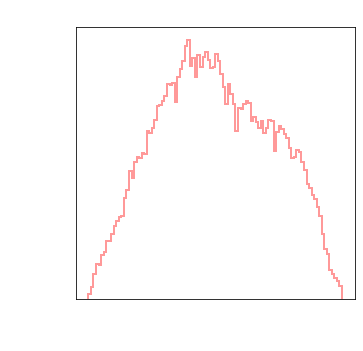

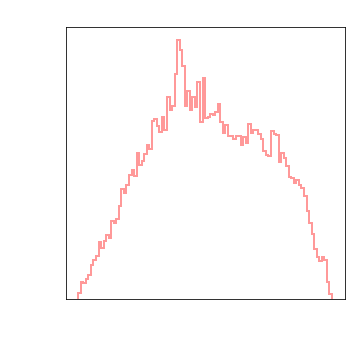

In [13]:
plot_orientation_effect(table_fil, title='Lowz+CMASS')
plot_orientation_effect(table_fil2)

In [14]:
def len_orientation_cut(table_fil, len_low=30, len_high=100, ang_low=40, ang_high=90):
    
    length_fil_arr = table_fil['Fil_lengths_Mpc']
    select_lengths = (length_fil_arr >= len_low) & (length_fil_arr <= len_high)
    
    angle = np.rad2deg(table_fil['Orientation_radian'])
    orientation_cut = (angle >= ang_low) & (angle <= ang_high)
    print(len(table_fil[select_lengths & orientation_cut]))
    return orientation_cut, select_lengths

print('\nLowz+CMASS\n------------')
orientation_cut, select_lengths = len_orientation_cut(table_fil)

print('\nLegacy MGS\n------------')
orientation_cut2, select_lengths2 = len_orientation_cut(table_fil2)


Lowz+CMASS
------------
18417

Legacy MGS
------------
3224


### Elongation of the filaments

In [84]:
def plot_elongation_effect(table_fil, orientation_cut, select_lengths, title='MGS'):
    elongation = np.rad2deg(table_fil['Elongation'])
    elongation = elongation[orientation_cut & select_lengths]
    print(title, len(elongation))
    fig, ax = plt.subplots(1, 1, figsize=(5, 5))

    out_angle = ax.hist(elongation, histtype='step', linewidth=2, 
                    color='#ff9999', bins=100, label = 'Full sample')
    fo.set_as_white(ax)
    fo.set_labels(ax, xlabel='Elongation', ylabel = 'Number of filaments',
                 title=f'{title}', log_scale=[True, 'y'], xlim=[0, 15])
    return

Lowz+CMASS 18417
MGS 3224


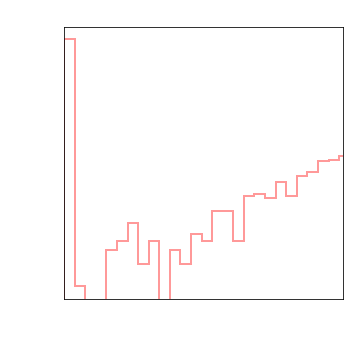

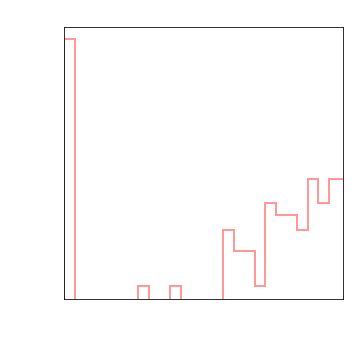

In [85]:
plot_elongation_effect(table_fil, orientation_cut, select_lengths, title='Lowz+CMASS')
plot_elongation_effect(table_fil2, orientation_cut2, select_lengths2)

In [82]:
print("total filaments available ", len(table_fil[(table_fil['Ownership']=='DE')]) + len(table_fil[(table_fil['Ownership']=='RU')]))
print("===========\n")
print("German half of the sky has:")
print("Total ",len(table_fil[(table_fil['Ownership']=='DE') ]))
print("Length and orientation cut", len(table_fil[(table_fil['Ownership']=='DE') & orientation_cut & select_lengths]))
print("Only length cut", len(table_fil[(table_fil['Ownership']=='DE') & select_lengths]))
print("Only orientation cut ", len(table_fil[(table_fil['Ownership']=='DE') & orientation_cut ]))
print("===========\n")
print("Russian half of the sky has:")
print("Total ",len(table_fil[(table_fil['Ownership']=='RU')]))
print("Length and orientation cut", len(table_fil[(table_fil['Ownership']=='RU') & select_lengths & orientation_cut]))
print("Only length cut", len(table_fil[(table_fil['Ownership']=='RU') & select_lengths]))
print("Only orientation cut", len(table_fil[(table_fil['Ownership']=='RU') & orientation_cut ]))
print("===========\n")

total filaments available  63391

German half of the sky has:
Total  45025
Length and orientation cut 10067
Only length cut 28142
Only orientation cut  16400

Russian half of the sky has:
Total  18366
Length and orientation cut 8350
Only length cut 11320
Only orientation cut 13494



The entire redshift range is plotted for the LOWZ+CMASS survey

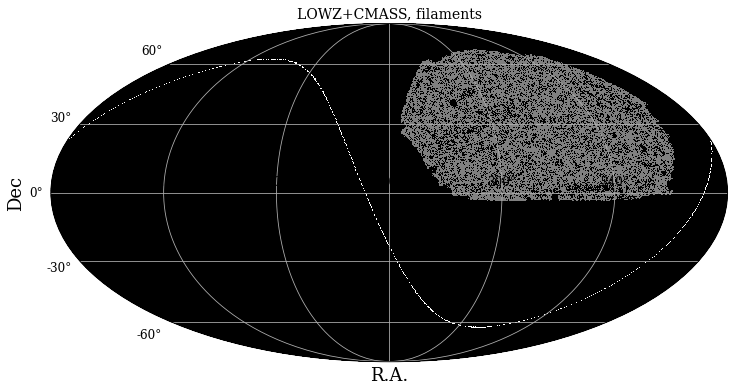

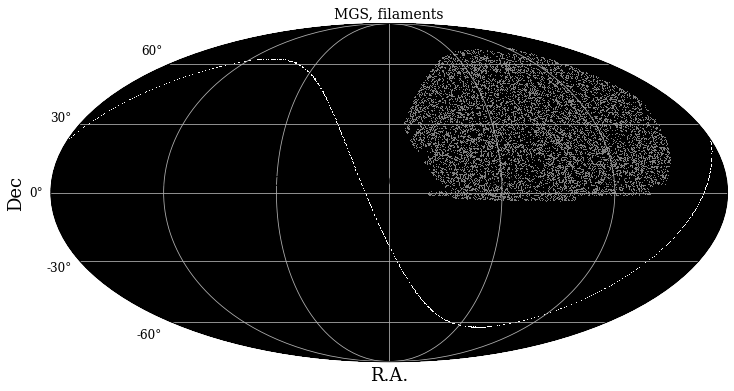

In [83]:
fil_map_processed = plot_healpy_maps(this_file, base_name, title='LOWZ+CMASS',  NSIDE=256, 
                                     z_low=0, z_high=1)
fil_map_processed2 = plot_healpy_maps(this_file, base_name2, title='MGS', NSIDE=256)

In [ ]:
def select_z(table_fil, z_low=0.1, z_high=0.5):
    z_cut = table_fil['redshift']
    z_cut = (z_arr >= z_low) & (z_arr <= z_high)
    return z_cut